# A Data Driven Analysis of Global Shipping Emissions - Methodology

A two-vessel replication of Selin et al. (2021), *Mitigation of CO₂ emissions frominternational shipping through national allocation* (Environ. Res. Lett. 16, 045009), built entirely from public data.

This notebook walks through `docs/METHODOLOGY.md` section by section, Section 0 to Section 8. It demonstrates the pipeline; it does not reimplement it. Every computation calls into `src/emissions_allocation/`, and every physical formula is cited to its source inline.

## How to read the numbers

Two of the parameters this model needs : installed power and design speed : cannot be observed from any free source. Selin et al. used IHS World Register of Shipping, a paid commercial register. The IMO's own fallback regressions are mutually circular. So three estimates are carried in parallel with no primary, and the spread between them is a reported result rather than an error to be resolved.

Anything derived rather than observed is marked [estimated]. A reader should never be unsure which is which.

## Scope

Two vessels demonstrate the *machinery* of national allocation. They cannot reproduce the paper's *findings*, which are distributional : top-20 rankings, concentration shares, the OECD split. Those need the full fleet.

What two vessels can show is the paper's equity argument in miniature, and they do:
COSCO ITALY's four allocation options collapse onto one national budget, while RCC AMERICA's land on three. Allocation choice is immaterial for the co-located majority and decisive for open-registry ships.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from emissions_allocation import Database, load_config
from emissions_allocation import activity, allocation, baselines, impacts, specs, validate

FIG_SINGLE = (6.5, 4.0)
FIG_MAP = (7.0, 6.0)
FIG_PANEL = (13.0, 4.0)
FIG_GRID = (13.0, 9.0)
DPI_SAVE = 300

pd.set_option("display.width", 120)
SET2 = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3",
        "#A6D854", "#FFD92F", "#E5C494", "#B3B3B3",
        "#1B9E77", "#D95F02", "#7570B3", "#E7298A",
        "#66A61E", "#E6AB02", "#A6761D", "#666666"]
COLOUR = dict(teal=SET2[0], orange=SET2[1], blue=SET2[2], pink=SET2[3],
              green=SET2[4], yellow=SET2[5], sand=SET2[6], gray=SET2[7],
              dark_teal=SET2[8], dark_orange=SET2[9], purple=SET2[10],
              magenta=SET2[11], olive=SET2[12], gold=SET2[13],
              brown=SET2[14], dark_gray=SET2[15])
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10,
                     "axes.prop_cycle": plt.cycler(color=SET2)})

cfg = load_config()
INTERIM = cfg.path("interim")
vessel = next(iter(cfg))
vessel_id = f"{vessel.shipnames[0]} (IMO {vessel.imo})"

print(f"study period   {cfg.start_date} to {cfg.end_date} ({cfg.elapsed_hours:,} hours)")
print(f"vessels        {[v.imo for v in cfg]}")
print(f"scenarios      {len(cfg.scenarios())}")

study period   2017-01-01 to 2024-12-31 (70,128 hours)
vessels        ['9516454', '9277802']
scenarios      16


# Section 0 : Select vessels

What this step does. Chooses the study vessels by reproducible criteria rather than by
hand, so a researcher extending this work applies the same filter to any number of ships.

Inputs : GFW 4Wings presence at world extent, filtered by flag and vessel type.
Outputs : `config/pilot.yaml`, with the criteria values that justified each selection.

Candidate discovery cannot use the ship-name filter, because names are what we are searching
*for*. It uses `flag` and `vessel_type` instead : the other two presence filters that bind.

### Both vessels selected

`selection.py` runs Section 0.2 steps 1–4 against the live API. Discovery pooled 15,417 distinct
IMOs across eight sample days and six open registries, narrowed to those with a distinct
name present in every year and a Europe rotation, then pulled port-call data for the
shortlist.

Step 5 cannot be automated. Criterion 7 : registered-owner country ≠ flag country, the
whole point of vessel B : requires Equasis, which needs a logged-in account and publishes no
API. That step was closed by hand.

No IMO number anywhere in this project is recalled or invented; every candidate came from a
live presence query.

In [2]:
for v in cfg:
    print(f"IMO {v.imo}  ({v.label})  names={list(v.shipnames)}")
    print(f"  former identities outside the study period: "
          f"{list(v.former_shipnames_outside_period) or 'none'}")

print("\nAllocation keys, both Hong Kong treatments:")
for treatment in cfg.run["hk_treatments"]:
    summary = allocation.summarise_options(cfg, treatment)
    for row in summary.itertuples():
        keys = "  ".join(f"{o}={getattr(row, o)}" for o in allocation.ALLOCATION_OPTIONS)
        verdict = "DEGENERATE" if row.is_degenerate else f"{row.n_distinct_countries} budgets"
        print(f"  {treatment:18s} {keys}   -> {verdict}")

IMO 9516454  (A)  names=['COSCO ITALY']
  former identities outside the study period: ['NE116']
IMO 9277802  (B)  names=['RCC AMERICA', 'HOEGH AMERICA']
  former identities outside the study period: none

Allocation keys, both Hong Kong treatments:
  separate           flag=BHS  owner=IMN  manager=GRC  operator=IMN   -> 3 budgets
  separate           flag=HKG  owner=CHN  manager=CHN  operator=CHN   -> 2 budgets
  folded_into_china  flag=BHS  owner=IMN  manager=GRC  operator=IMN   -> 3 budgets
  folded_into_china  flag=HKG  owner=CHN  manager=CHN  operator=CHN   -> DEGENERATE


# Section 1 : Obtain ship activity data

What this step does. Produces a continuous, ordered, hourly position-and-speed series
across the study period, plus the sequence of port calls that defines the vessel's voyages.

Inputs : GFW 4Wings presence (`public-global-presence`), GFW Events
(`public-global-port-visits-events`), GFW Vessels identity.
Outputs : `vessel_hour`, `port_call`, `voyage_leg`.

### Section 1.5 Derived speed over ground

Great-circle distance between consecutive hourly positions, over elapsed time:

$$a = \sin^2\!\left(\tfrac{\Delta\varphi}{2}\right) + \cos\varphi_1\cos\varphi_2\,
      \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right)$$
$$d = 2R\arcsin\sqrt{a}, \qquad R = 6371.0088\ \text{km}$$
$$SOG_i = \frac{d}{1.852\,\Delta t}\quad[\text{knots}]$$

*Source: haversine formula; R is the IUGG mean Earth radius. `docs/METHODOLOGY.md` Section 1.5.*

`SOG` is the IMO's term, but note the provenance differs: in the Fourth GHG Study it is
*transmitted* by the vessel, whereas here it is *derived* from consecutive cell centroids.
Section 1.6 exists because of that difference.

### Section 1.6 Smoothing : not cosmetic

GFW credits each vessel-hour to a single 0.01° cell. A ship crossing ~22 cells per hour
lands unpredictably within them, so consecutive-centroid speeds oscillate. Because
propulsion power scales as $v^3$, the error does not average out:

$$\overline{SOG}_i = \frac{1}{w}\sum_{k=-(w-1)/2}^{+(w-1)/2} SOG_{i+k}$$

*Source: `docs/METHODOLOGY.md` Section 1.6. The window $w$ is a sensitivity axis, not a fixed choice.*

In [3]:
spine = pd.read_parquet(INTERIM / f"vessel_hour_{vessel.imo}.parquet")
port_calls = pd.read_parquet(INTERIM / f"port_call_{vessel.imo}.parquet")
legs = pd.read_parquet(INTERIM / f"voyage_leg_{vessel.imo}.parquet")

print(f"vessel_hour  {len(spine):,} rows")
print(f"port_call    {len(port_calls):,} rows, confidence {sorted(set(port_calls.confidence))}, "
      f"{port_calls.port_iso3.nunique()} countries")
print(f"voyage_leg   {len(legs):,} rows, {int(legs.is_eu_eu.sum())} EU->EU, "
      f"{int(legs.is_international.sum())} international")
port_calls.port_iso3.value_counts().head(8).to_frame("port calls").T

vessel_hour  70,128 rows
port_call    389 rows, confidence ['4'], 17 countries
voyage_leg   388 rows, 27 EU->EU, 225 international


port_iso3,CHN,TWN,USA,VNM,EGY,KOR,DEU,MYS
port calls,194,46,39,22,18,16,10,10


### Chart 1 : the oscillation smoothing corrects

Raw derived speed against the smoothed series, over a week of open-ocean cruising. The raw
trace swings wildly while the vessel is in fact holding a steady speed; that swing is
cell-centroid quantisation, not the ship.

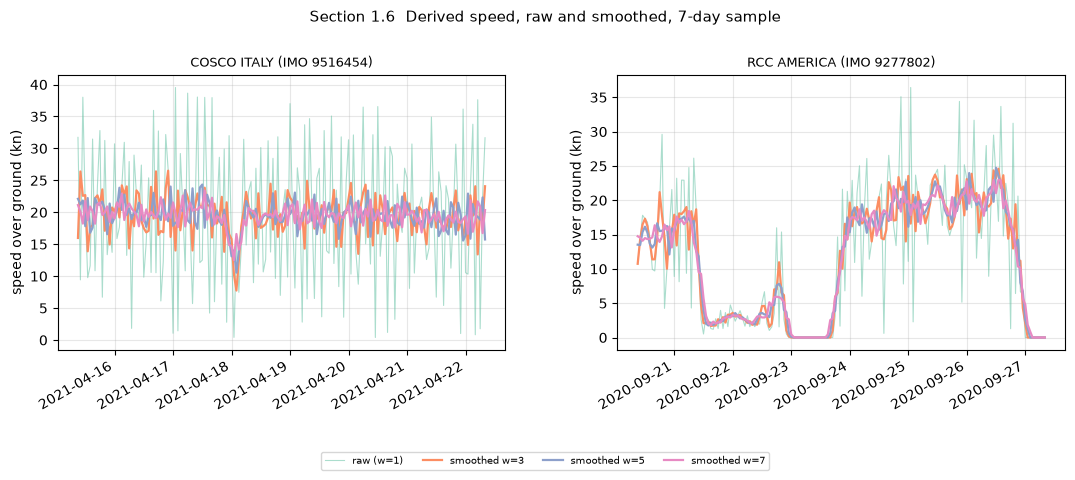

COSCO ITALY (IMO 9516454):
 window  mean(v^3)/(mean v)^3
      1              1.942910
      3              1.380464
      5              1.383254
      7              1.414544
RCC AMERICA (IMO 9277802):
 window  mean(v^3)/(mean v)^3
      1              2.060983
      3              1.485583
      5              1.486815
      7              1.516603


In [4]:
window_days = 7
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
for ax, v in zip(axes, cfg):
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    at_sea = vessel_spine[(~vessel_spine.is_inactive) & (vessel_spine.sog_raw > 8)]
    start = at_sea.ts.iloc[len(at_sea) // 2]
    sample = vessel_spine[(vessel_spine.ts >= start) & (vessel_spine.ts < start + pd.Timedelta(days=window_days))]
    ax.plot(sample.ts, sample.sog_raw, lw=0.8, alpha=0.55, label="raw (w=1)")
    for w in [w for w in cfg.run["smoothing_windows"] if w > 1]:
        ax.plot(sample.ts, sample[f"sog_w{w}"], lw=1.6, label=f"smoothed w={w}")
    ax.set_ylabel("speed over ground (kn)")
    ax.set_title(f"{v.shipnames[0]} (IMO {v.imo})", fontsize=9)
    ax.tick_params(axis="x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.3, top=0.85, wspace=0.25)
fig.legend(handles, labels, loc="lower center", ncol=len(labels), fontsize=7, bbox_to_anchor=(0.5, 0.06), borderaxespad=0)
fig.suptitle(f"Section 1.6  Derived speed, raw and smoothed, {window_days}-day sample", fontsize=11)
plt.show()

for v in cfg:
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    active = vessel_spine[~vessel_spine.is_inactive]
    bias = pd.DataFrame({"window": cfg.run["smoothing_windows"],
                         "mean(v^3)/(mean v)^3": [activity.cubic_bias(active[f"sog_w{w}"]) for w in cfg.run["smoothing_windows"]]})
    print(f"{v.shipnames[0]} (IMO {v.imo}):")
    print(bias.to_string(index=False))

In [5]:
_disabled_duplicate = """Duplicate standalone chart intentionally removed.
vessel_id = f"{v.shipnames[0]} (IMO {v.imo})"
vessel_estimates = specs.build_estimates(v, cfg)
env = cfg.defaults["fleet_speed_envelope"].get(v.require_spec("ship_type"))
fig, ax = plt.subplots(figsize=(11, 4))
if env is not None:
    ax.axhspan(env["min_kn"], env["max_kn"], color=COLOUR["green"], alpha=0.12,
               label=f"observed fleet envelope {env['min_kn']}–{env['max_kn']} kn")
    ax.axhline(env["max_kn"], color=COLOUR["green"], ls="--", lw=1)
for i, (name, e) in enumerate(vessel_estimates.items()):
    ax.scatter([i], [e.design_speed_kn], s=180, zorder=3,
               color=COLOUR["blue"] if env is None or e.within_fleet_envelope else COLOUR["pink"])
    ax.annotate(f"{e.design_speed_kn:.2f} kn\n{e.mcr_kw:,.0f} kW",
                (i, e.design_speed_kn), textcoords="offset points", xytext=(14, -6))
ax.set_xticks(range(len(vessel_estimates)))
ax.set_xticklabels([vessel_estimates[k].label for k in vessel_estimates])
ax.set_ylabel("design speed (kn)")
ax.set_ylim(0, 32)
ax.set_title(f"Design speed estimates : {vessel_id}")
if env is not None:
    ax.legend(loc="lower right", fontsize=9)
plt.show()
"""


### Section 1.7 Coverage : and a finding the specification did not anticipate

`docs/METHODOLOGY.md` Section 1.7 and Section 4.5 treat the coverage correction as negligible, on the
strength of 2024 alone (99.98%). Measured across the full period it is not.

More importantly, the gaps are two different phenomena and they need opposite treatment:

* Scattered short gaps are thin AIS reception. The vessel was trading and hours were
  missed, so $E/\text{coverage}$ correctly recovers them.
* Contiguous absences are the hull out of service. Zero presence hours *and* zero port
  calls, from two independent endpoints. Scaling those up would fabricate voyages.

Applied uniformly, the Section 4.5 correction would multiply 2019 by 2.77× for a ship that was
laid up for 282 days. So `coverage_active` : observed over *in-service* hours : is what
the correction divides by.

In [6]:
coverage = pd.concat([
    activity.coverage_by_year(pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")).assign(
        ship=v.shipnames[0], IMO=v.imo
    )
    for v in cfg
], ignore_index=True)
display(coverage[["ship", "IMO", "year", "coverage_raw", "coverage_active"]].style.format({
    "coverage_raw": "{:.2%}", "coverage_active": "{:.2%}",
}).set_caption("Section 1.7 coverage by vessel: raw counts a lay-up as missing data; active does not"))

print("Out-of-service windows (no presence AND no port calls):")
for v in cfg:
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    gaps = activity.find_gaps(vessel_spine, min_hours=cfg.run["inactivity_gap_days"] * 24)
    print(f"  {v.shipnames[0]} (IMO {v.imo}):")
    if gaps.empty:
        print("    none")
    for g in gaps.itertuples():
        print(f"    {g.start_ts:%Y-%m-%d} to {g.end_ts:%Y-%m-%d}  "
              f"{int(g.hours):,} h ({int(g.hours)//24} d)")

,ship,IMO,year,coverage_raw,coverage_active
0,COSCO ITALY,9516454,2017,82.02%,82.02%
1,COSCO ITALY,9516454,2018,71.15%,88.39%
2,COSCO ITALY,9516454,2019,36.06%,81.97%
3,COSCO ITALY,9516454,2020,72.72%,92.34%
4,COSCO ITALY,9516454,2021,93.18%,93.18%
5,COSCO ITALY,9516454,2022,97.01%,97.01%
6,COSCO ITALY,9516454,2023,99.81%,99.81%
7,COSCO ITALY,9516454,2024,99.98%,99.98%
8,RCC AMERICA,9277802,2017,85.63%,85.63%
9,RCC AMERICA,9277802,2018,88.71%,88.71%


Out-of-service windows (no presence AND no port calls):
  COSCO ITALY (IMO 9516454):
    2019-06-10 to 2020-03-18  6,772 h (282 d)
    2018-05-19 to 2018-07-29  1,708 h (71 d)
  RCC AMERICA (IMO 9277802):
    2024-10-28 to 2024-12-31  1,551 h (64 d)


### Chart 3: hourly tracks for both vessels

This world map places every observed vessel-hour at its 0.01 degree cell centroid. Comparing
the two tracks confirms the spatial coverage used in the activity and emissions calculations.

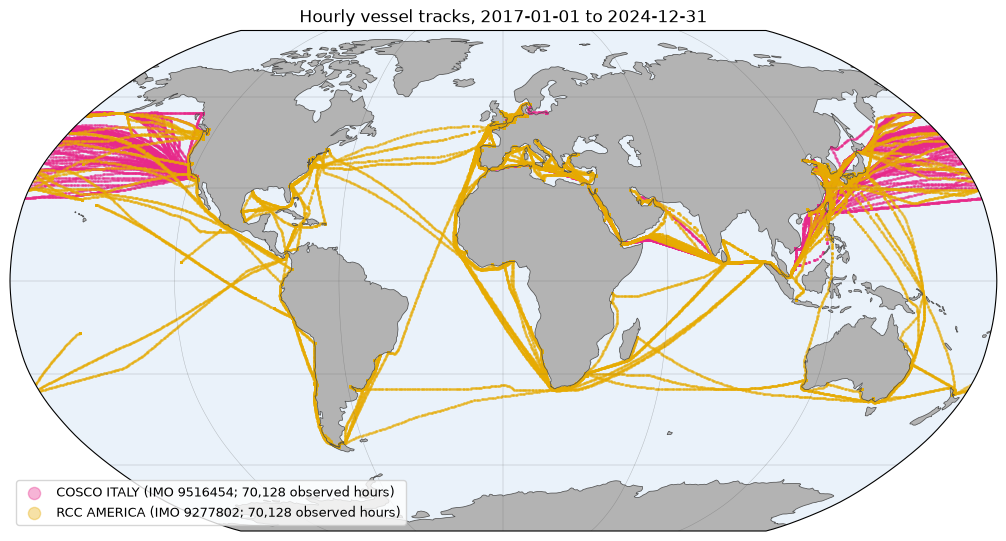

In [7]:
track_colours = [COLOUR["magenta"], COLOUR["gold"]]
fig = plt.figure(figsize=(13, 6.5))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor=COLOUR["gray"])
ax.add_feature(cfeature.OCEAN, facecolor="#EAF2FA")
ax.coastlines(linewidth=0.55, color="#4D4D4D")
ax.gridlines(linewidth=0.35, color="#4D4D4D", alpha=0.35, draw_labels=False)

for v, colour in zip(cfg, track_colours):
    vessel_track = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet").dropna(
        subset=["lat", "lon"]
    )
    scatter_kwargs = {"s": 1.2, "alpha": 0.35, "color": colour,
                      "label": f"{v.shipnames[0]} (IMO {v.imo}; {len(vessel_track):,} observed hours)"}
    scatter_kwargs["transform"] = ccrs.PlateCarree()
    ax.scatter(vessel_track.lon, vessel_track.lat, **scatter_kwargs)

ax.set_title(f"Hourly vessel tracks, {cfg.start_date} to {cfg.end_date}")
ax.legend(markerscale=8, fontsize=9, loc="lower left")
plt.show()

# Section 2 : Ship specifications and parameters

What this step does. Assembles the technical parameters the emission model needs, and is
explicit that two of them cannot be observed from any free source.

Inputs : Equasis, public vessel registers, published regressions.
Outputs : `config/vessel_specs.yaml`, every estimated field carrying `value`, `source`
and `method`.

### Section 2.1 TEU capacity

IMO Table 17 indexes container ships by TEU; Equasis does not carry it. Invert the beam
relation:

$$B = 3.27\,\mathrm{TEU}^{0.29} \quad\Longrightarrow\quad
  \mathrm{TEU} = \left(\frac{B}{3.27}\right)^{1/0.29}$$

*Source: Cepowski & Chorab (2021), Ocean Engineering 238, 109727 : beam relation, fitted on
215 container designs built 2015–2020.*

Beam is the better proxy for container ships because it sets the on-deck row count.

### Section 2.2 Design speed and installed power : three estimates

Estimate A : IMO EEXI curve fit

$$V = A\cdot \mathrm{DWT}^{B}, \qquad P_{ME} = C\cdot \mathrm{DWT}^{D}$$

*Source: IMO Resolution MEPC.333(76) (2021), Table 1. Containership: A=3.240, B=0.183,
C=0.504, D=1.030.* The resolution writes $P_{ME}$ for installed power; this project calls
it `MCR` throughout, because the Fourth GHG Study uses that symbol for instantaneous demand.

Estimate B : Admiralty coefficient, calibrated

$$Fn = \frac{v}{\sqrt{g\,L_{BP}}} \quad\Longrightarrow\quad
  V = \frac{Fn\sqrt{g\,L_{BP}}}{0.5144}\ [\text{kn}]$$
$$\mathrm{MCR} = \frac{\Delta^{2/3}\,V^{3}}{C_{adm}}$$

*Sources: Froude number, standard naval architecture. $C_{adm}$ calibrated on Charchalis
(2014), Journal of KONES 21(2), Table 1 : 17 container ships with matched speed, power and
displacement: median 482.*

Displacement by two routes, which bracket a real convention difference:

$$\Delta = C_B\,L_{BP}\,B\,T\,\rho \qquad\text{and}\qquad \Delta = \mathrm{DWT}/0.80$$

Estimate C : sourced specification. Open item 4. Not found; raises rather than guessing.

In [8]:
rows = []
for v in cfg:
    ship_type = v.require_spec("ship_type")
    table17_size = (f"{specs.resolve_teu(v, cfg):,.0f} TEU (derived)"
                    if ship_type == "container"
                    else f"{v.require_spec('dwt'):,.0f} t DWT")
    rows.append({
        "ship": v.shipnames[0],
        "IMO": v.imo,
        "ship type": ship_type,
        "flag": v.require_spec("flag"),
        "built": v.require_spec("year_built"),
        "DWT (t)": v.require_spec("dwt"),
        "GT (t)": v.require_spec("gt"),
        "LOA (m)": v.specs["loa_m"].value if "loa_m" in v.specs else np.nan,
        "beam (m)": v.specs["beam_m"].value if "beam_m" in v.specs else np.nan,
        "draught (m)": v.specs["draught_m"].value if "draught_m" in v.specs else np.nan,
        "engine type": v.require_spec("engine_type"),
        "IMO Table 17 size input": table17_size,
        "power estimates": ", ".join(v.resolve_power_estimates(cfg.run["power_estimates"])),
    })

display(pd.DataFrame(rows).style.format({
    "DWT (t)": "{:,.0f}", "GT (t)": "{:,.0f}",
    "LOA (m)": "{:.1f}", "beam (m)": "{:.1f}", "draught (m)": "{:.1f}",
}, na_rep=":").set_caption("Section 2 : vessel specifications and parameters used in the emissions model"))

for v in cfg:
    if "beam_m" in v.specs:
        teu = specs.resolve_teu(v, cfg)
        print(f"{v.shipnames[0]} (IMO {v.imo}): TEU inverted from beam {v.require_spec('beam_m')} m: {teu:,.0f} [estimated]")
    else:
        print(f"{v.shipnames[0]} (IMO {v.imo}): TEU inversion not applicable: beam_m is not required for this vehicle carrier.")
validation_rows = []
estimate_rows = []
for v in cfg:
    if {"lbp_m", "beam_m", "draught_m"}.issubset(v.specs):
        validation = pd.DataFrame(specs.validate_hull_relations(v, cfg.defaults)).T.reset_index(names="relation")
        validation.insert(0, "IMO", v.imo)
        validation.insert(0, "ship", v.shipnames[0])
        validation_rows.append(validation)
    else:
        validation_rows.append(pd.DataFrame([{"ship": v.shipnames[0], "IMO": v.imo, "relation": "not applicable", "predicted": np.nan, "observed": np.nan, "error_pct": np.nan}]))
    for estimate in specs.build_estimates(v, cfg).values():
        estimate_rows.append({"ship": v.shipnames[0], "IMO": v.imo, "estimate": estimate.label, "design speed (kn)": estimate.design_speed_kn, "MCR (kW)": estimate.mcr_kw, "within fleet envelope": estimate.within_fleet_envelope, "estimated": estimate.estimated})
display(pd.concat(validation_rows, ignore_index=True).style.format({"predicted": "{:.1f}", "observed": "{:.1f}", "error_pct": "{:.1f}"}).set_caption("Section 2  Cepowski and Chorab DWT relations by vessel"))
display(pd.DataFrame(estimate_rows).style.format({"design speed (kn)": "{:.2f}", "MCR (kW)": "{:,.0f}"}).set_caption("Section 2.2  Three estimates by vessel"))


,ship,IMO,ship type,flag,built,DWT (t),GT (t),LOA (m),beam (m),draught (m),engine type,IMO Table 17 size input,power estimates
0,COSCO ITALY,9516454,container,HKG,2014,"156,610","154,592",365.9,51.2,16.0,SSD,"13,174 TEU (derived)","A, B"
1,RCC AMERICA,9277802,vehicle,BHS,2003,"21,182","57,718",:,:,:,SSD,"21,182 t DWT",A


COSCO ITALY (IMO 9516454): TEU inverted from beam 51.2 m: 13,174 [estimated]
RCC AMERICA (IMO 9277802): TEU inversion not applicable: beam_m is not required for this vehicle carrier.


,ship,IMO,relation,predicted,observed,error_pct
0,COSCO ITALY,9516454,lbp,344.4,345.0,-0.2
1,COSCO ITALY,9516454,beam,52.8,51.2,3.2
2,COSCO ITALY,9516454,draught,15.8,16.0,-1.4
3,RCC AMERICA,9277802,not applicable,nan,nan,nan


,ship,IMO,estimate,design speed (kn),MCR (kW),within fleet envelope,estimated
0,COSCO ITALY,9516454,A (EEXI curve fit),25.55,"67,912",False,True
1,COSCO ITALY,9516454,"B (Admiralty, calibrated)",22.62,"78,258",True,True
2,RCC AMERICA,9277802,A (EEXI curve fit),19.96,"14,086",None,True


### Chart 2 : estimate A falls outside the modern container fleet

`D = 1.030` makes power nearly *linear* in deadweight, which breaks at the top of the
container range where modern designs are deliberately under-powered for slow steaming.

The predicted 28.92 kn exceeds 24.5 kn, the maximum service speed among 215 distinct
container designs built since 2015 (Cepowski & Chorab, Table 1). This is a reported
validation failure, not something corrected : the estimate is carried through to the CO₂
result so a reader can see what an out-of-envelope power assumption does.

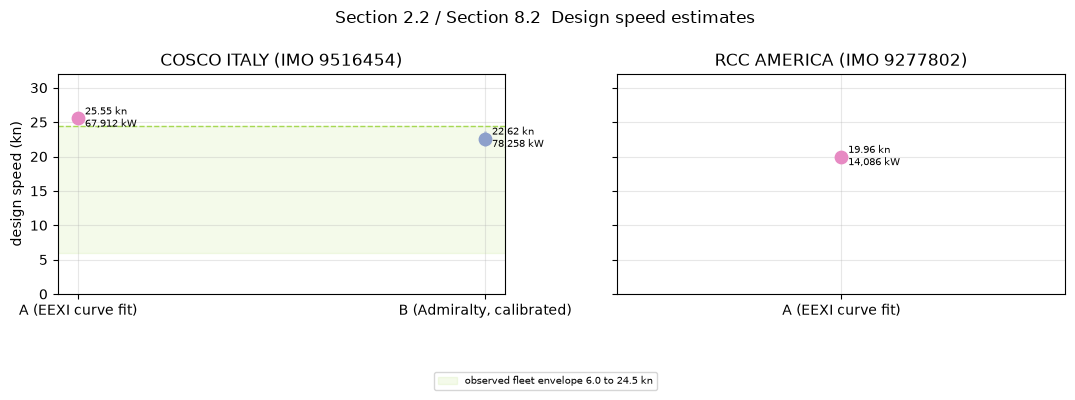

In [9]:
fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL, sharey=True)
for ax, v in zip(axes, cfg):
    vessel_estimates = specs.build_estimates(v, cfg)
    env = cfg.defaults["fleet_speed_envelope"].get(v.require_spec("ship_type"))
    if env is not None:
        ax.axhspan(env["min_kn"], env["max_kn"], color=COLOUR["green"], alpha=0.12, label=f"observed fleet envelope {env['min_kn']} to {env['max_kn']} kn")
        ax.axhline(env["max_kn"], color=COLOUR["green"], ls="--", lw=1)
    for i, estimate in enumerate(vessel_estimates.values()):
        ax.scatter([i], [estimate.design_speed_kn], s=80, zorder=3, color=COLOUR["blue"] if estimate.within_fleet_envelope else COLOUR["pink"])
        ax.annotate(f"{estimate.design_speed_kn:.2f} kn\n{estimate.mcr_kw:,.0f} kW", (i, estimate.design_speed_kn), textcoords="offset points", xytext=(5, -6), fontsize=7)
    if "B" in vessel_estimates:
        lo, hi = vessel_estimates["B"].variants["speed_kn_range"]
        ax.vlines(list(vessel_estimates).index("B"), lo, hi, color=COLOUR["blue"], lw=2, alpha=0.5)
    ax.set_xticks(range(len(vessel_estimates)))
    ax.set_xticklabels([estimate.label for estimate in vessel_estimates.values()])
    ax.set_ylim(0, 32)
    ax.set_title(f"{v.shipnames[0]} (IMO {v.imo})")
axes[0].set_ylabel("design speed (kn)")
handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.27, top=0.82, wspace=0.25)
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), fontsize=7, bbox_to_anchor=(0.5, 0.03), borderaxespad=0)
fig.suptitle("Section 2.2 / Section 8.2  Design speed estimates")
plt.show()


# Section 3 : Fuel type and emission factors

What this step does. Assigns a fuel to every vessel-hour and attaches the corresponding
emission factor and specific fuel consumption.

Inputs : IMO Fourth GHG Study Tables 19 and 21; Marine Regions ECA polygons (MARPOL
Annex VI Reg. 14); `voyage_leg` from Section 1.
Outputs : `fuel_assignment` at vessel-hour grain.

### Section 3.1 Assignment rule

A vessel-hour burns distillate (MDO/MGO) when *any* of the following holds, and
residual (HFO) otherwise:

1. the main engine is high-speed : not applicable here (SSD);
2. the position falls inside an ECA polygon : point-in-polygon;
3. the hour belongs to a voyage leg between two EU ports.

*Source: Selin et al. (2021), following the IMO Fourth GHG Study.*

Condition 3 is read from an actual port-call sequence, which is a genuine improvement on the
EEZ proxy that gridded-only data would have forced.

### Section 3.2 The IMO 2020 sulphur cap is immaterial to CO₂

The study period straddles the 0.50% global sulphur cap of 1 January 2020. For CO₂ this
changes nothing: the Fourth GHG Study assigns low-sulphur HFO the same carbon content and
emission factor as HFO (Table 21, LSHFO 1.0% → 3.114). Scrubber fitting affects SOx only.
There is deliberately no fuel-switch date branch anywhere in the code.

*Source: IMO Fourth GHG Study 2020, Table 21 (printed p.74).*

In [10]:
fuel_assign = pd.concat([
    pd.read_parquet(INTERIM / f"fuel_assignment_{v.imo}.parquet").assign(ship=v.shipnames[0], IMO=v.imo)
    for v in cfg
], ignore_index=True)
total = len(fuel_assign)
print(f"{total:,} vessel-hours")
print(f"  inside an ECA:    {int(fuel_assign.in_eca.sum()):,} "
      f"({fuel_assign.in_eca.mean():.1%})")
print(f"  on an EU->EU leg: {int(fuel_assign.is_eu_eu_leg.sum()):,} "
      f"({fuel_assign.is_eu_eu_leg.mean():.1%})")

ef = cfg.factors["emission_factors"]["fuels"]
split = (fuel_assign.groupby(["ship", "IMO", "fuel_type"]).size().rename("hours").reset_index()
         .assign(share=lambda d: d["hours"] / d.groupby("IMO")["hours"].transform("sum"),
                 ef_f=lambda d: d["fuel_type"].map(lambda fuel: ef[fuel]["ef_f"])))
display(split.style.format({"hours": "{:,}", "share": "{:.1%}"})
        .set_caption("Section 3.3  fuel split by vessel and Table 21 emission factors (g CO2 / g fuel)"))

print("\nECA hours by area (corroborates the port-call pattern independently):")
print(fuel_assign[fuel_assign.in_eca].eca_area.value_counts().to_string())

140,256 vessel-hours
  inside an ECA:    12,799 (9.1%)
  on an EU->EU leg: 4,616 (3.3%)


,ship,IMO,fuel_type,hours,share,ef_f
0,COSCO ITALY,9516454,HFO,"64,841",92.5%,3.114000
1,COSCO ITALY,9516454,MDO,"5,287",7.5%,3.206000
2,RCC AMERICA,9277802,HFO,"59,587",85.0%,3.114000
3,RCC AMERICA,9277802,MDO,"10,541",15.0%,3.206000



ECA hours by area (corroborates the port-call pattern independently):
eca_area
North Sea area                      6581
North American area 1               4406
North American area 2               1642
Baltic Sea area                      147
United States Caribbean sea area      23


# Section 4 : Calculate CO₂ emissions

What this step does. Converts the hourly activity series into CO₂ mass per hour, summed
to ship-year, for every scenario.

Inputs : `vessel_hour`, `vessel_specs`, `fuel_assignment`, IMO Tables 16, 17, 19, 21.
Outputs : `emissions_hour`, `emissions_year`, both scenario-keyed.

### Section 4.2 Main-engine power demand

$$Load_i = \left(\frac{\overline{SOG}_i}{V}\right)^{3}\!\!,\ \text{capped at }1.0
\qquad \dot W_{ME,i} = \mathrm{MCR}\cdot Load_i$$

*Source: `docs/METHODOLOGY.md` Section 4.2; the cubic law is standard propulsion theory.*

with $\dot W_{ME,i}=0$ below 7% MCR and in the At berth / Anchored modes.
*Source: IMO Fourth GHG Study 2020, printed p.70 : "At engine loads below 7%, fuel
consumption and all the emissions derived from the main engine are assumed to be zero."*

### Section 4.4 Load-corrected specific fuel consumption : IMO equation (10), verbatim

$$SFC_{ME,i} = SFC_{base}\cdot\underbrace{\left(0.455\,Load_i^{2} − 0.710\,Load_i + 1.280\right)}_{CF_L}$$

*Source: IMO Fourth GHG Study 2020, equation (10), printed p.71.*

The quadratic minimises at $Load = 0.710/(2\times0.455) = 0.78$, matching the study's stated
~80% MCR optimum : an internal check that the coefficients are transcribed correctly, and one
the test suite asserts.

Auxiliary engines and boilers are not corrected : IMO equation (11):

$$FC_{AE|BO,i} = SFC_{base}\cdot \dot W_{AE|BO,i}$$

### Section 4.5 Hourly and annual CO₂

$$FC_i = \left[\dot W_{ME,i}SFC_{ME,i} + \dot W_{AE,i}SFC_{base,AE}
        + \dot W_{BO,i}SFC_{base,BO}\right]\Delta t \quad[\text{g fuel}]$$
$$E_{CO_2,i} = FC_i\cdot EF_f / 10^{6}\quad[\text{t}], \qquad
  E_{ship,y} = \sum_i E_{CO_2,i}$$

*Source: IMO Fourth GHG Study 2020 Section 2.2; emission factors from Table 21.*

$LLF$ does not appear: CO₂'s low-load factor is 1.00 at every load (Table 20), because CO₂
varies directly with fuel consumption, which is already load-dependent.

### Section 4.1 Operating mode : IMO Table 16, and one documented departure

Table 16 assigns one of five phases from speed, main-engine load, distance to port and
distance to coast. The five columns are an ordered ladder; the first applicable wins.

*Source: IMO Fourth GHG Study 2020, Table 16, printed p.66.*

Two things about this table are worth stating, because both differ from
`docs/METHODOLOGY.md` Section 4.1:

The 'Port 1–5 nm' column is tanker-only. The source footnotes it: *"Applicable to
chemical tankers, liquified gas tankers, oil tankers and other liquids tankers only"* :
liquid tankers are lightered offshore and so can berth within 5 nm of port. The methodology
document reproduces the column without that restriction, which would let a container ship
count as At berth up to 5 nm out. The source is followed here.

At berth is determined from port-visit intervals, not distance. The source separates
berth from anchor by distance because it had no better signal, and Section 4.1 flags the exposure.
We have a better one: a GFW port-visit event asserts, from a different endpoint and with a
confidence score, that the vessel was in port between two timestamps. Using distance to
anchorage coordinates instead put only 1,143 h at berth against 17,427 h actually in port.
`run.use_port_visit_intervals: false` restores strict Table 16 for comparison.

In [11]:
hourly = pd.concat([
    pd.read_parquet(INTERIM / f"emissions_hour_{v.imo}.parquet").assign(ship=v.shipnames[0], IMO=v.imo)
    for v in cfg
], ignore_index=True)
yearly = pd.read_parquet(INTERIM / f"emissions_year_{vessel.imo}.parquet")

ref = hourly[hourly.scenario_id == f"{cfg.run['power_estimates'][0]}_w3"]
mode_split = (ref.groupby(["ship", "IMO", "operating_mode"]).size().rename("hours").reset_index()
              .assign(share=lambda d: d["hours"] / d.groupby("IMO")["hours"].transform("sum")))
display(mode_split.style.format({"hours": "{:,}", "share": "{:.1%}"})
        .set_caption("Section 4.1  operating-mode split by vessel (estimate A, w=3)"))

t17 = cfg.factors["auxiliary_boiler_power"]
band = next(b for b in t17["ship_types"]["container"]["bands"] if b["min"] == 12000)
display(pd.DataFrame({"mode": t17["modes"], "boiler kW": band["boiler"],
                      "auxiliary kW": band["auxiliary"]})
        .set_index("mode").T.style.set_caption(
            "Section 4.3  IMO Table 17 : container 12,000–14,499 TEU"))

,ship,IMO,operating_mode,hours,share
0,COSCO ITALY,9516454,anchored,"2,474",4.0%
1,COSCO ITALY,9516454,at_berth,"14,900",24.2%
2,COSCO ITALY,9516454,manoeuvring,681,1.1%
3,COSCO ITALY,9516454,normal_cruising,"3,514",5.7%
4,COSCO ITALY,9516454,slow_transit,"40,079",65.0%
5,RCC AMERICA,9277802,anchored,"5,389",7.9%
6,RCC AMERICA,9277802,at_berth,"11,751",17.1%
7,RCC AMERICA,9277802,manoeuvring,961,1.4%
8,RCC AMERICA,9277802,normal_cruising,"15,830",23.1%
9,RCC AMERICA,9277802,slow_transit,"34,646",50.5%


mode,at_berth,anchored,manoeuvring,sea
boiler kW,630,630,630,0
auxiliary kW,1300,1800,3250,2050


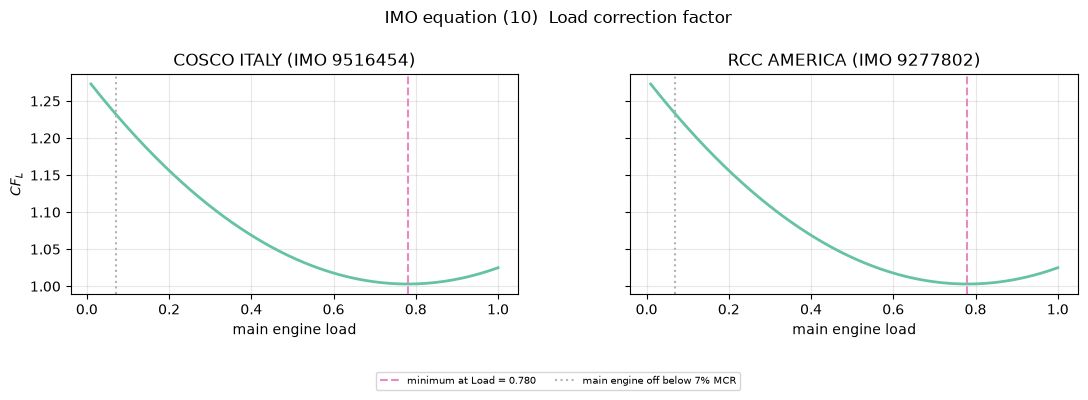

In [12]:
c = cfg.factors["load_correction"]
loads = np.linspace(0.01, 1.0, 400)
cf_l = c["a"] * loads**2 + c["b"] * loads + c["c"]
fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL, sharey=True)
for ax, v in zip(axes, cfg):
    ax.plot(loads, cf_l, color=COLOUR["teal"], lw=2)
    ax.axvline(c["minimises_at"], color=COLOUR["pink"], ls="--", label=f"minimum at Load = {c['minimises_at']:.3f}")
    ax.axvline(c["main_engine_cutoff_load"], color=COLOUR["gray"], ls=":", label=f"main engine off below {c['main_engine_cutoff_load']:.0%} MCR")
    ax.set_xlabel("main engine load")
    ax.set_title(f"{v.shipnames[0]} (IMO {v.imo})")
axes[0].set_ylabel("$CF_L$")
handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.27, top=0.82, wspace=0.25)
fig.legend(handles, labels, loc="lower center", ncol=len(labels), fontsize=7, bbox_to_anchor=(0.5, 0.03), borderaxespad=0)
fig.suptitle("IMO equation (10)  Load correction factor")
plt.show()


### Chart 4 : annual CO₂ under each power estimate

The gap between the two series is the Section 2.2 spread propagating into the result. It is an
uncertainty band, not an error: no free source supplies installed power, so there is no basis
for preferring either.

Years flagged low-confidence had thin AIS reception, and 2018 and 2019 also contain the
out-of-service windows found in Section 1.7.

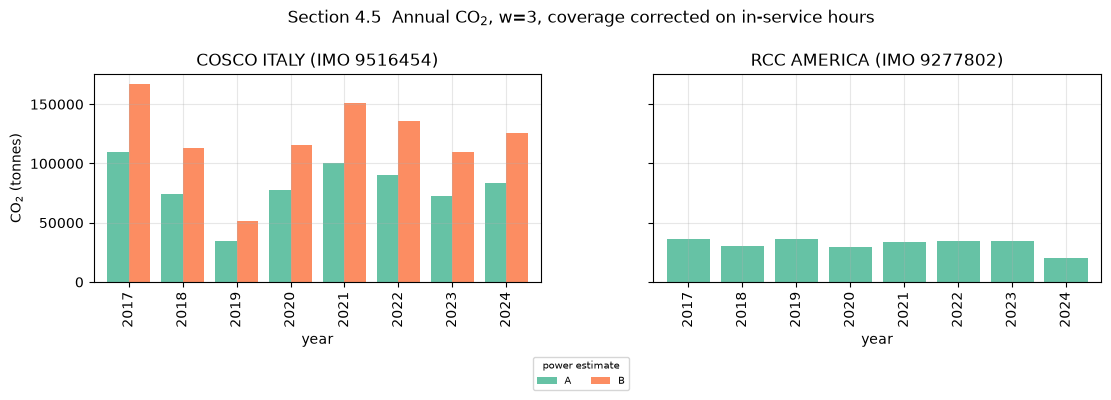

,ship,IMO,year,power_estimate,co2_tonnes
0,COSCO ITALY,9516454,2017,A,"109,768"
1,COSCO ITALY,9516454,2017,B,"167,140"
2,COSCO ITALY,9516454,2018,A,"74,338"
3,COSCO ITALY,9516454,2018,B,"112,820"
4,COSCO ITALY,9516454,2019,A,"34,307"
5,COSCO ITALY,9516454,2019,B,"51,199"
6,COSCO ITALY,9516454,2020,A,"77,374"
7,COSCO ITALY,9516454,2020,B,"115,377"
8,COSCO ITALY,9516454,2021,A,"100,757"
9,COSCO ITALY,9516454,2021,B,"150,753"


,ship,IMO,power_estimate,co2_tonnes
0,COSCO ITALY,9516454,A,"642,683"
1,COSCO ITALY,9516454,B,"969,081"
2,RCC AMERICA,9277802,A,"256,011"


In [13]:
w = 3
annual_table = pd.concat([
    pd.read_parquet(INTERIM / f"emissions_year_{v.imo}.parquet").query("smoothing_window == @w").assign(ship=v.shipnames[0], IMO=v.imo)
    for v in cfg
], ignore_index=True)[["ship", "IMO", "year", "power_estimate", "co2_tonnes"]]
fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL, sharey=True)
for ax, v in zip(axes, cfg):
    vessel_annual = annual_table[annual_table.IMO == v.imo]
    vessel_annual.pivot_table(index="year", columns="power_estimate", values="co2_tonnes").plot(kind="bar", ax=ax, width=0.8, legend=False)
    ax.set_title(f"{v.shipnames[0]} (IMO {v.imo})")
    ax.set_xlabel("year")

axes[0].set_ylabel("CO$_2$ (tonnes)")
handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.30, top=0.82, wspace=0.25)
fig.legend(handles, labels, title="power estimate", loc="lower center", ncol=len(labels), fontsize=7, title_fontsize=7, bbox_to_anchor=(0.5, 0.03), borderaxespad=0)
fig.suptitle(f"Section 4.5  Annual CO$_2$, w={w}, coverage corrected on in-service hours")
plt.show()
display(annual_table.style.format({"co2_tonnes": "{:,.0f}"}).set_caption(f"Section 4.5  Annual CO2 (t) by vessel and power estimate, w={w}"))
totals = annual_table.groupby(["ship", "IMO", "power_estimate"], as_index=False).co2_tonnes.sum()
display(totals.style.format({"co2_tonnes": "{:,.0f}"}).set_caption(f"Section 4.5  Eight-year CO2 total (t) by vessel and power estimate, w={w}"))


# Section 5 : Allocate to countries

What this step does. Attributes annual CO₂ to countries under each allocation rule.

$$E_{c,\text{option}} = \sum_{\text{ships}} E_{\text{ship}}\cdot
  \mathbb{1}\!\left[\text{key}_{\text{option}}(\text{ship}) = c\right]$$

*Source: Selin et al. (2021) Section 2.*

Four of the paper's five options are reproduced. The fifth : bunker fuel : rests on
national marine-bunker *sales* statistics, and allocating one ship's emissions to a bunkering
country would require knowing where it took fuel, which no public dataset records. It is out
of scope by construction, not by omission.

Two caveats on the keys, both from Section 5.2:

* Operator is a proxy. Equasis has no operator field; commercial manager stands in. This
  partially collapses the operator and manager options.
* Equasis gives an address, not a country of incorporation. GFW's `registryOwners.flag`
  returns HKG for this Shanghai-registered owner : it appears to echo the ship's flag rather
  than owner domicile, and is not used.

# Section 6 : Compare with carbon budgets

$$B_c\,[\text{Mt CO}_2] = B_c\,[\text{Mt C}]\times 3.664$$

*Source: Global Carbon Budget 2025, National Fossil Carbon Emissions v2025, sheet
"Territorial Emissions" (header at row index 11). The GCB reports million tonnes of
carbon, not CO₂.*

National columns already exclude bunker fuels : only the World total includes them : so the
denominator is clean and adding shipping emissions does not double-count.

### Section 6.4 The Hong Kong question : resolved against the paper itself

Selin et al.'s supplementary Table 1 carries 199 countries and no Hong Kong row. No
Taiwan, no Macao either: it is aligned strictly to the UNFCCC party list. The paper folds
Hong Kong into China, so `folded_into_china` is the replication-faithful treatment.

Both are still computed, because the two baselines differ by a factor of 369 and that gap is
itself the methodological finding.

In [14]:
base = baselines.build_baselines(cfg)
b2024 = base[base.year == 2024]
rows = []
for t in cfg.run["hk_treatments"]:
    sub = b2024[b2024.hk_treatment == t]
    hk = sub[sub.country == "Hong Kong"].mtco2
    rows.append({"treatment": t,
                 "Hong Kong (Mt CO2)": hk.iloc[0] if len(hk) else np.nan,
                 "China (Mt CO2)": sub[sub.country == "China"].mtco2.iloc[0]})
display(pd.DataFrame(rows).style.format({"Hong Kong (Mt CO2)": "{:,.1f}",
                                         "China (Mt CO2)": "{:,.1f}"}, na_rep="folded in")
        .set_caption("Section 6.4  2024 national baselines under each treatment"))

check = baselines.shipping_cross_check(cfg, 2024)
print(f"Section 6.2 cross-check : GCB 'International Shipping' 2024: "
      f"{check['mtc']:.2f} MtC = {check['mtco2']:.0f} Mt CO2")
print("  (an independent global total to sanity-check any fleet-scale result)")

,treatment,Hong Kong (Mt CO2),China (Mt CO2)
0,separate,33.3,"12,289.0"
1,folded_into_china,folded in,"12,322.4"


Section 6.2 cross-check : GCB 'International Shipping' 2024: 170.15 MtC = 623 Mt CO2
  (an independent global total to sanity-check any fleet-scale result)


# Section 7 : Compute allocation impacts

$$\Delta E_c = E_c, \qquad
  \Delta E\%_c = 100\cdot\frac{\Delta E_c}{B_c}, \qquad
  \text{rank}_c = \mathrm{RANK}()\ \text{over}\ (\text{option},\text{scenario})$$

*Source: Selin et al. (2021) Section 3.*

Ranking and concentration shares are structurally meaningless at n = 1 : with one country
per option the top-20 share is always 1.0. The code path exists and is exercised because the
fleet-scale version needs it, and it is labelled rather than interpreted.

### Chart 5 : the allocation comparison

This is the headline methodological result. Identical emissions, two territory
conventions: the same tonnage is a ~370× larger share of Hong Kong's budget than of
China's. Nothing the ship did changes; only the convention does.

Two vessels, opposite behaviour under the same rules. This is the paper's equity
finding reproduced at n = 2:

* COSCO ITALY : a Hong Kong flag with all three commercial roles in China. Under the
  paper's own territory alignment all four options land on one national budget. The
  choice of allocation rule is *immaterial* for this hull.
* RCC AMERICA : a Bahamas flag, an Isle of Man owner and operator, a Greek manager.
  The four options land on three budgets. The choice of rule is *decisive*.

Neither is exceptional. Selin et al. find 74% of ships have owner, operator and manager
in one country, covering 61% of emissions : the co-located majority COSCO ITALY belongs
to. The ships the rule moves are systematically those on open registries, and RCC AMERICA
is one of them.

Allocation keys side by side -- the qualitative result at n = 2:


option,ship,imo,flag,manager,operator,owner,n_distinct_countries,is_degenerate,hk_treatment
0,RCC AMERICA,9277802,BHS,GRC,IMN,IMN,3,False,separate
1,COSCO ITALY,9516454,HKG,CHN,CHN,CHN,2,False,separate


option,ship,imo,flag,manager,operator,owner,n_distinct_countries,is_degenerate,hk_treatment
0,RCC AMERICA,9277802,BHS,GRC,IMN,IMN,3,False,folded_into_china
1,COSCO ITALY,9516454,HKG,CHN,CHN,CHN,1,True,folded_into_china


,option,country,gcb_name,hk_treatment,power_estimate,delta_e_mt,baseline_mt,delta_e_pct
170,flag,HKG,China,folded_into_china,A,0.0832,"12,322.4",0.000675
171,flag,BHS,Bahamas,folded_into_china,A,0.0203,3.1,0.662009
177,flag,HKG,China,folded_into_china,B,0.1261,"12,322.4",0.001023
182,flag,HKG,Hong Kong,separate,A,0.0832,33.3,0.249678
183,flag,BHS,Bahamas,separate,A,0.0203,3.1,0.662009
189,flag,HKG,Hong Kong,separate,B,0.1261,33.3,0.378289
362,manager,CHN,China,folded_into_china,A,0.0832,"12,322.4",0.000675
363,manager,GRC,Greece,folded_into_china,A,0.0203,53.4,0.038083
369,manager,CHN,China,folded_into_china,B,0.1261,"12,322.4",0.001023
374,manager,CHN,China,separate,A,0.0832,"12,289.0",0.000677


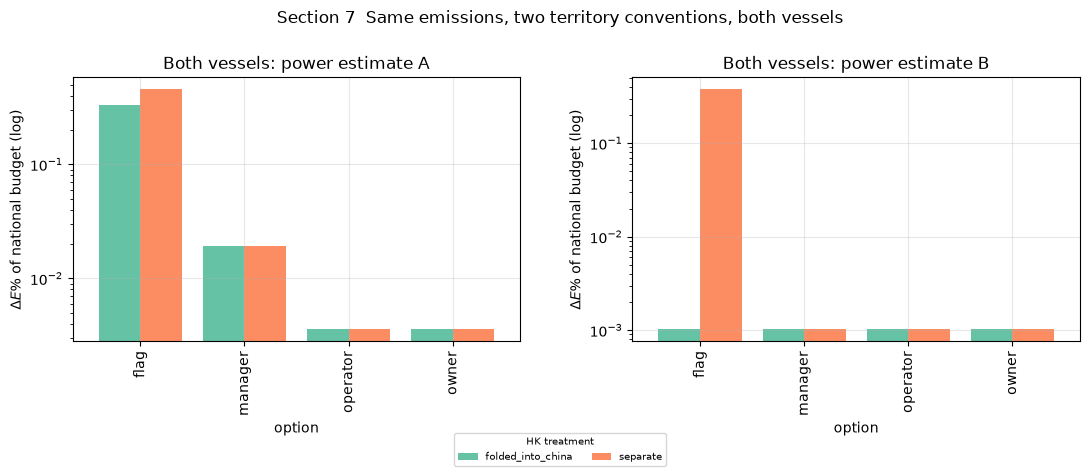

,option,country,hk_treatment,delta_e_mt_min,delta_e_mt_max,spread_ratio
7,flag,BHS,folded_into_china,0.0195,0.0218,1.12x
15,flag,BHS,separate,0.0195,0.0218,1.12x
23,flag,HKG,folded_into_china,0.0796,0.1330,1.67x
31,flag,HKG,separate,0.0796,0.1330,1.67x
39,manager,CHN,folded_into_china,0.0796,0.1330,1.67x
47,manager,CHN,separate,0.0796,0.1330,1.67x
55,manager,GRC,folded_into_china,0.0195,0.0218,1.12x
63,manager,GRC,separate,0.0195,0.0218,1.12x
71,operator,CHN,folded_into_china,0.0796,0.1330,1.67x
79,operator,CHN,separate,0.0796,0.1330,1.67x


In [15]:
im = pd.read_parquet(INTERIM / "impacts.parquet")
view = im[(im.smoothing_window == 3) & (im.year == 2024)]

print("Allocation keys side by side -- the qualitative result at n = 2:")
for treatment in cfg.run["hk_treatments"]:
    summary = allocation.summarise_options(cfg, treatment)
    ship_by_imo = {v.imo: v.shipnames[0] for v in cfg}
    summary.insert(0, "ship", summary.imo.map(ship_by_imo))
    display(summary.style.set_caption(f"Section 5.1  allocation keys by vessel, HK treatment: {treatment}"))

display(view[["option", "country", "gcb_name", "hk_treatment", "power_estimate",
              "delta_e_mt", "baseline_mt", "delta_e_pct"]]
        .sort_values(["option", "hk_treatment", "power_estimate"])
        .style.format({"delta_e_mt": "{:.4f}", "baseline_mt": "{:,.1f}",
                       "delta_e_pct": "{:.6f}"})
        .set_caption("Section 7  2024 allocation impacts, w=3"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, est in zip(axes, sorted(view.power_estimate.unique())):
    d = view[view.power_estimate == est]
    p = d.pivot_table(index="option", columns="hk_treatment", values="delta_e_pct")
    p.plot(kind="bar", ax=ax, logy=True, width=0.8, legend=False)
    ax.set_title(f"Both vessels: power estimate {est}")
    ax.set_ylabel(r"$\Delta E\%$ of national budget (log)")

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.29, top=0.84, wspace=0.25)
fig.legend(handles, labels, title="HK treatment", loc="lower center", ncol=len(labels), fontsize=7, title_fontsize=7, bbox_to_anchor=(0.5, 0.03), borderaxespad=0)
fig.suptitle("Section 7  Same emissions, two territory conventions, both vessels")
plt.show()

spread = impacts.scenario_spread(im)
display(spread[spread.year == 2024][["option", "country", "hk_treatment",
                                     "delta_e_mt_min", "delta_e_mt_max", "spread_ratio"]]
        .style.format({"delta_e_mt_min": "{:.4f}", "delta_e_mt_max": "{:.4f}",
                       "spread_ratio": "{:.2f}x"})
        .set_caption("Section 8.1  scenario spread : the uncertainty band, not an error"))

# Section 8 : Sensitivity and validation

### Section 8.1 The two dominant drivers

1. Installed power and design speed : three estimates, no primary.
2. Speed-smoothing window : the $v^3$ bias.

Remaining uncertainties : coverage correction, displacement convention, TEU estimation,
engine-type assignment : are documented qualitatively rather than propagated.

### Section 8.2 Validation

`THETIS-MRV` is used only to validate, never as an input : it is EU-scope and this study
allocates globally. Feeding it back would make the comparison circular and import an EU
boundary into a global allocation.

In [16]:
validation_summaries = []
for v in cfg:
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    vessel_port_calls = pd.read_parquet(INTERIM / f"port_call_{v.imo}.parquet")
    vessel_legs = pd.read_parquet(INTERIM / f"voyage_leg_{v.imo}.parquet")
    vessel_hourly = pd.read_parquet(INTERIM / f"emissions_hour_{v.imo}.parquet")
    vessel_yearly = pd.read_parquet(INTERIM / f"emissions_year_{v.imo}.parquet")
    checks = validate.run_all(cfg, v, vessel_spine, vessel_port_calls, vessel_legs, activity.coverage_by_year(vessel_spine), vessel_hourly, vessel_yearly, specs.build_estimates(v, cfg))
    summary = validate.summarise(checks)
    summary.insert(0, "IMO", v.imo)
    summary.insert(0, "ship", v.shipnames[0])
    validation_summaries.append(summary)
display(pd.concat(validation_summaries, ignore_index=True).style.set_caption("Section 8.2  Validation summary by vessel"))


,ship,IMO,check,status,detail,basis
0,COSCO ITALY,9516454,Identity integrity,PASS,one IMO throughout: 9516454,distinct IMO in vessel_hour
1,COSCO ITALY,9516454,Hour conservation,WARN,"8 years, active coverage 82.0%-100.0%; below 95% in 5 year(s): 2017 82.0%, 2018 88.4%, 2019 82.0%, 2020 92.3%, 2021 93.2%",observed hours / in-service hours
2,COSCO ITALY,9516454,Leg-speed plausibility,PASS,"346 legs with movement, median 13.2 kn, 95th pct 19.3 kn; 5 legs above 30.0 kn are anchorage-segmentation artefacts, not voyages (5/5 same-country, 0 same-port, 1.0 h = 0.00% of leg time)",great-circle distance / leg duration; impossible legs diagnosed
3,COSCO ITALY,9516454,Port-call/track agreement,PASS,"20,107 h at berth/anchored/manoeuvring against 17,427 h inside port visits (ratio 1.15)",modes vs event intervals
4,COSCO ITALY,9516454,Fleet envelope,FAIL,A at 25.55 kn outside the published range (inside: B),observed service-speed range for the ship type
5,COSCO ITALY,9516454,Smoothing sensitivity,PASS,w=1:1.94x w=3:1.38x w=5:1.38x w=7:1.41x (lowest at w=3),mean(v^3)/(mean v)^3 over in-service hours
6,COSCO ITALY,9516454,THETIS-MRV,PASS,"1 year(s) comparable in MRV scope; modelled/verified A=0.64x, B=0.98x (closest: B); at_dock covers 17% of calls",modelled emissions restricted to MRV scope against EMSA-verified figures -- the only external ground truth in this project
7,RCC AMERICA,9277802,Identity integrity,PASS,one IMO throughout: 9277802,distinct IMO in vessel_hour
8,RCC AMERICA,9277802,Hour conservation,WARN,"8 years, active coverage 84.5%-99.1%; below 95% in 5 year(s): 2017 85.6%, 2018 88.7%, 2019 87.1%, 2020 88.4%, 2021 84.5%",observed hours / in-service hours
9,RCC AMERICA,9277802,Leg-speed plausibility,PASS,"515 legs with movement, median 11.5 kn, 95th pct 17.2 kn; 1 legs above 30.0 kn are anchorage-segmentation artefacts, not voyages (1/1 same-country, 0 same-port, 0.1 h = 0.00% of leg time)",great-circle distance / leg duration; impossible legs diagnosed


## What remains open

These are stated rather than worked around. Each is a named error or a PENDING marker in the
code, never a substituted default.

### Status review

Vessel B selection is closed: RCC AMERICA (IMO 9277802) is configured. The smoothing-window decision is closed for this pilot: full-series diagnostics select w=3. THETIS-MRV validation is partly closed because EU-scope annual comparisons are available, but no global external inventory is available. Estimate C and the joint-regime/overlapping-claim EEZ rule remain open.

| # | Item | Effect |
|---|---|---|
| 1 | Vessel B not selected | Allocation is degenerate at n = 1; Section 0.2 steps 1–4 are automated, step 5 needs Equasis |
| 2 | ~~Selin supplementary Table 1~~ | Closed : 199 countries, no Hong Kong row; the paper folds it into China |
| 3 | ~~Coastline layer~~ | Closed : land derived from EEZ_land_union minus EEZ v12 |
| 4 | Estimate C | No free source for installed power / design speed; raises on use |
| 5 | Smoothing window | Now measured across the full series, not one day: bias 1.94× → 1.38× at w=3 |
| 6 | Joint-regime EEZs | Default `ISO_SOV1`, affected hours reported separately |
| 7 | THETIS-MRV export | Annual CO₂ remains UNVERIFIED against external ground truth |

### Findings that contradict the specification

* Coverage is not uniform. Section 1.7 and Section 4.5 assume it is negligible from 2024 alone. It runs
  36%–99.98%, and two contiguous lay-ups mean a uniform correction would fabricate voyages.
* Table 16's Port 1–5 nm column is tanker-only. Section 4.1 reproduces it without the footnote.
* At berth cannot be found from anchorage distance. Port-visit intervals are used instead.
* Estimate B's power range is wider than quoted. Section 2.2 rounds the Froude speeds to 22–23 kn;
  the full 21.48–23.75 kn range gives 64,788–93,656 kW rather than 69,600–85,100 kW.